# Multi-Class Human Activity Recognition using Smartphone Sensor Data

## PROJECT TITLE:
Multiclass Classification of Human Activities Using Smartphone Sensor Data

## RESEARCH QUESTION:
Can machine learning models accurately classify human activities
into various categories using accelerometer and gyroscope
sensor data collected from smartphones?

## 1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
classification_report,
roc_auc_score,
roc_curve
)

## 2. DATA LOADING

The UCI HAR dataset consists of engineered time- and frequency-domain
features extracted from accelerometer and gyroscope signals collected
via smartphones worn at the waist.

In [ ]:
X_train = pd.read_csv(
r'/content/X_train.txtvv',
sep=r'\s+',
header=None
)

X_test = pd.read_csv(
r'/content/X_test.txtv',
sep=r'\s+',
header=None
)

y_train = pd.read_csv(
r'/content/y_train.txt',
header=None
)

y_test = pd.read_csv(
r'/content/y_test.txt',
header=None
)

activity_labels = pd.read_csv(
r'/content/activity_labels.txtv',
sep=' ',
header=None,
index_col=0
)

features = pd.read_csv(
    r'/content/features.txt',
    sep=r'\s+',
    header=None
)


# 3. Labels

Mapping numeric labels to activity names

In [ ]:
y_train = y_train[0].map(activity_labels[1])
y_test  = y_test[0].map(activity_labels[1])

print("Unique Classes:", y_train.unique())

Unique Classes: <StringArray>
[          'STANDING',            'SITTING',             'LAYING',
            'WALKING', 'WALKING_DOWNSTAIRS',   'WALKING_UPSTAIRS']
Length: 6, dtype: str


## 4. EDA

### Class distribution

This shows whether the dataset is balanced.

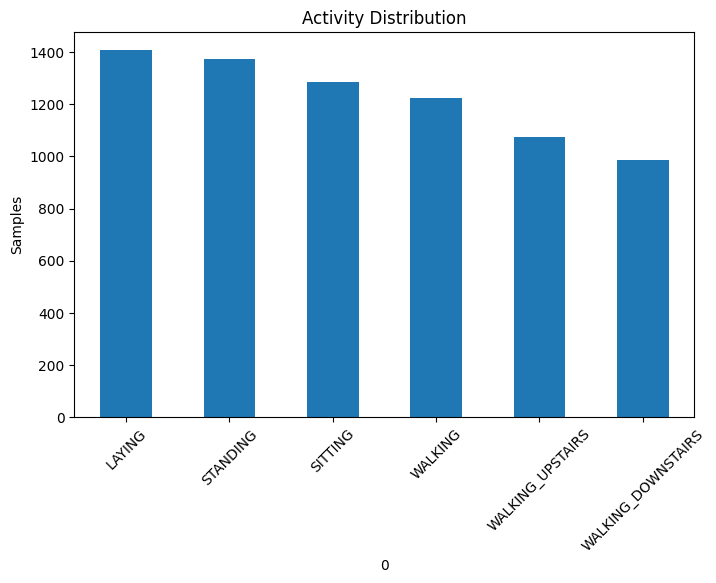

In [ ]:
plt.figure(figsize=(8,5))
y_train.value_counts().plot(kind='bar')
plt.title("Activity Distribution")
plt.ylabel("Samples")
plt.xticks(rotation=45)
plt.show()

Now we look at feature spread

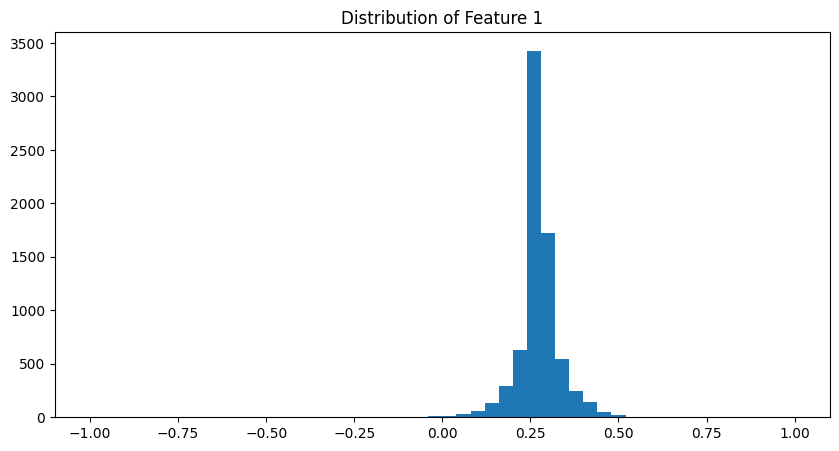

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(X_train.iloc[:,0], bins=50)
plt.title("Distribution of Feature 1")
plt.show()

### Correlation Heatmap

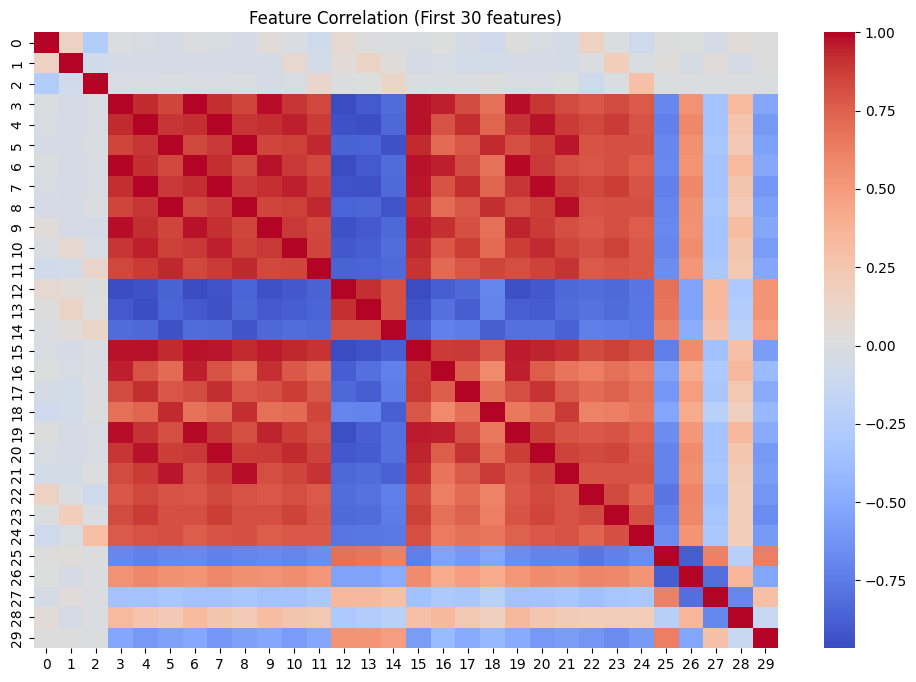

In [ ]:
import seaborn as sns

corr = X_train.iloc[:, :30].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation (First 30 features)")
plt.show()

# PCA Visualization

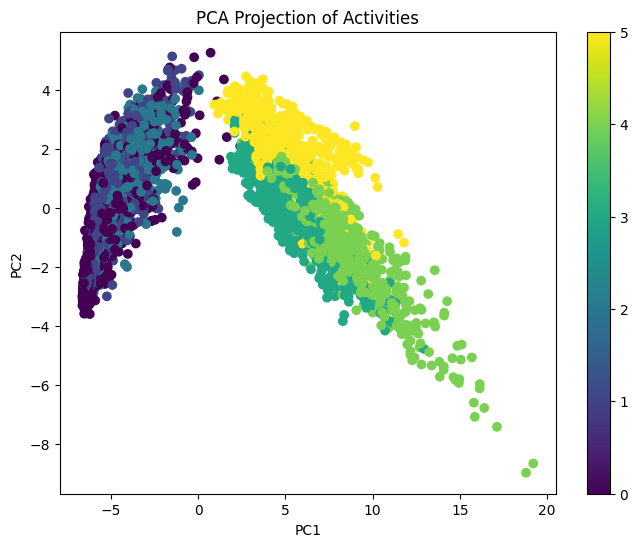

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train.astype('category').cat.codes)

plt.title("PCA Projection of Activities")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter)
plt.show()

### t-SNE Visualization

t-SNE is a non-linear dimensionality reduction that often reveals class clusters better than PCA, especially when classes are not linearly separable.

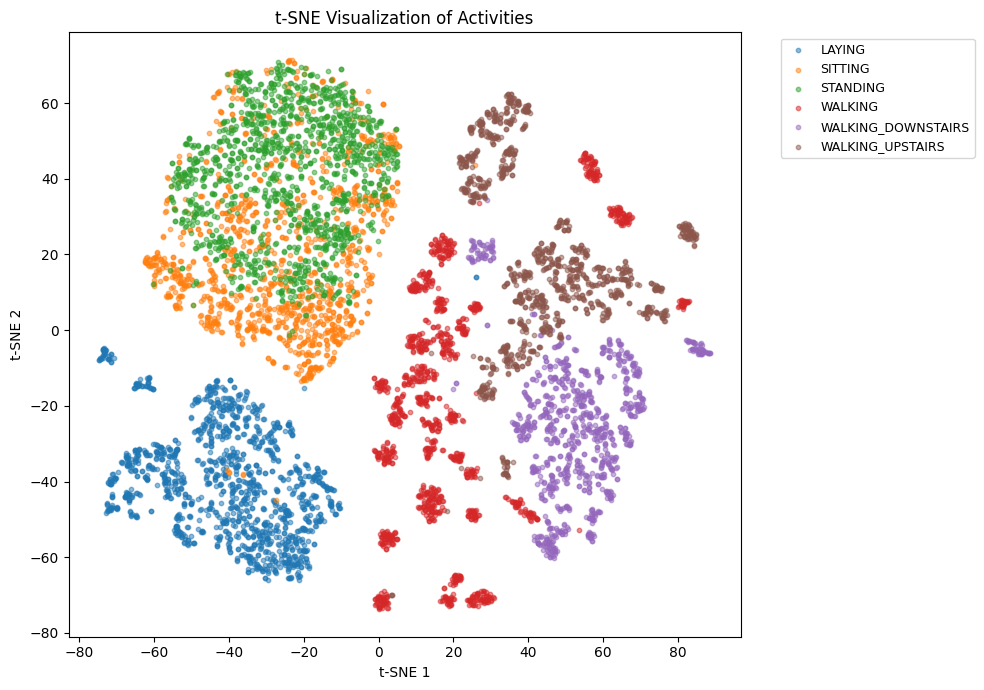

In [ ]:
from sklearn.manifold import TSNE

# Use PCA first to speed up t-SNE (561 → 50 dims)
X_pca_50 = PCA(n_components=50).fit_transform(X_train)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca_50)

plt.figure(figsize=(10, 7))
labels = y_train.astype("category")
for activity in labels.cat.categories:
    mask = labels == activity
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=activity, alpha=0.5, s=10)

plt.title("t-SNE Visualization of Activities")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### Feature Importance Preview (Random Forest)

A quick Random Forest fit to rank features by their Gini importance — showing which sensor signals are most useful for distinguishing activities.

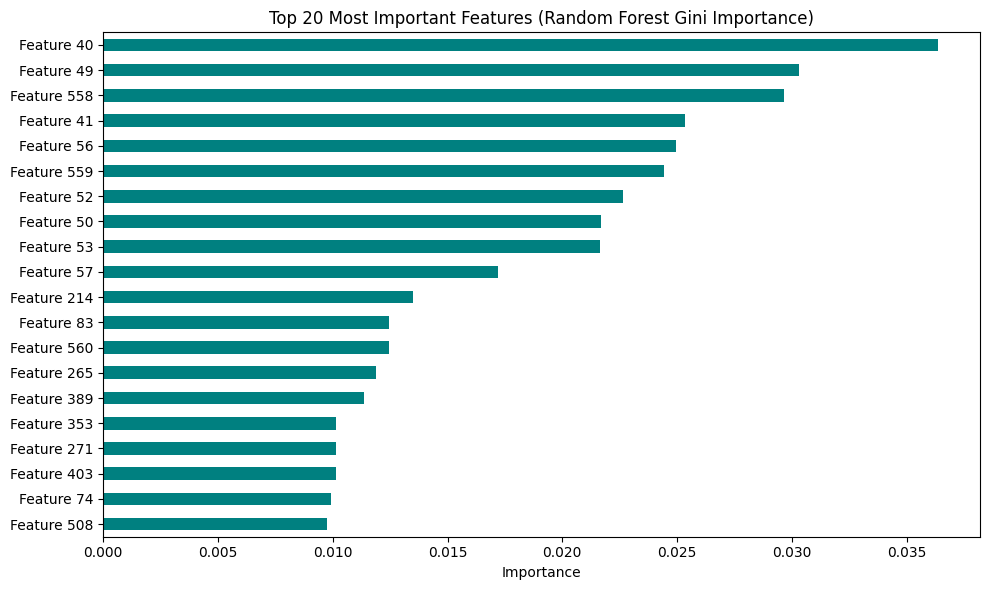

Top 5 features: ['Feature 40', 'Feature 49', 'Feature 558', 'Feature 41', 'Feature 56']


In [ ]:
# Quick Random Forest for feature importance
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_train, y_train)

importances = pd.Series(rf_temp.feature_importances_, index=[f"Feature {i}" for i in range(X_train.shape[1])])
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind="barh", color="teal")
plt.title("Top 20 Most Important Features (Random Forest Gini Importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 features:", top20.head(5).index.tolist())

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

def plot_confusion_matrix(clf, y_pred, y_test):
    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=clf.classes_,
                yticklabels=clf.classes_)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

def print_metrics(name, y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec  = recall_score(y_test, y_pred, average="weighted")
    f1   = f1_score(y_test, y_pred, average="weighted")

    print(f"\n{'='*50}")
    print(f"  {name} — Overall Metrics")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}  (weighted)")
    print(f"  F1 Score  : {f1:.4f}  (weighted)")
    print(f"{'='*50}")
    print(f"\nPer-Class Report:\n")
    print(classification_report(y_test, y_pred))

## 5. Model Training And Evaluation

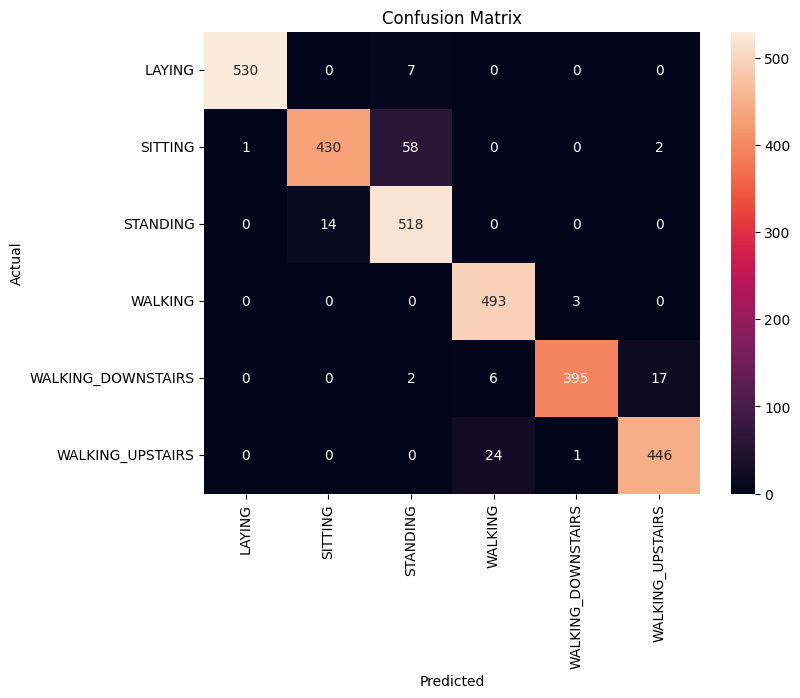


  Logistic Regression — Overall Metrics
  Accuracy  : 0.9542
  Precision : 0.9561  (weighted)
  Recall    : 0.9542  (weighted)
  F1 Score  : 0.9542  (weighted)

Per-Class Report:

                    precision    recall  f1-score   support

            LAYING       1.00      0.99      0.99       537
           SITTING       0.97      0.88      0.92       491
          STANDING       0.89      0.97      0.93       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.96      0.95      0.95       471

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



In [ ]:
name = "Logistic Regression"
model = LogisticRegression(max_iter=500)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

plot_confusion_matrix(clf, y_pred, y_test)
print_metrics(name, y_test, y_pred)

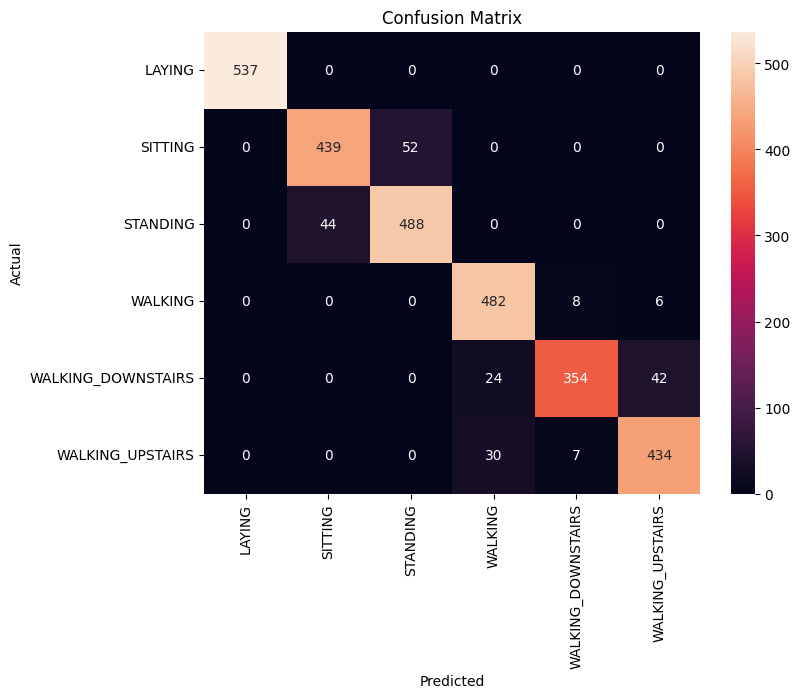


  Random Forest — Overall Metrics
  Accuracy  : 0.9277
  Precision : 0.9288  (weighted)
  Recall    : 0.9277  (weighted)
  F1 Score  : 0.9274  (weighted)

Per-Class Report:

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.90      0.97      0.93       496
WALKING_DOWNSTAIRS       0.96      0.84      0.90       420
  WALKING_UPSTAIRS       0.90      0.92      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [ ]:
name = "Random Forest"
model = RandomForestClassifier(n_estimators=200)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

plot_confusion_matrix(clf, y_pred, y_test)
print_metrics(name, y_test, y_pred)

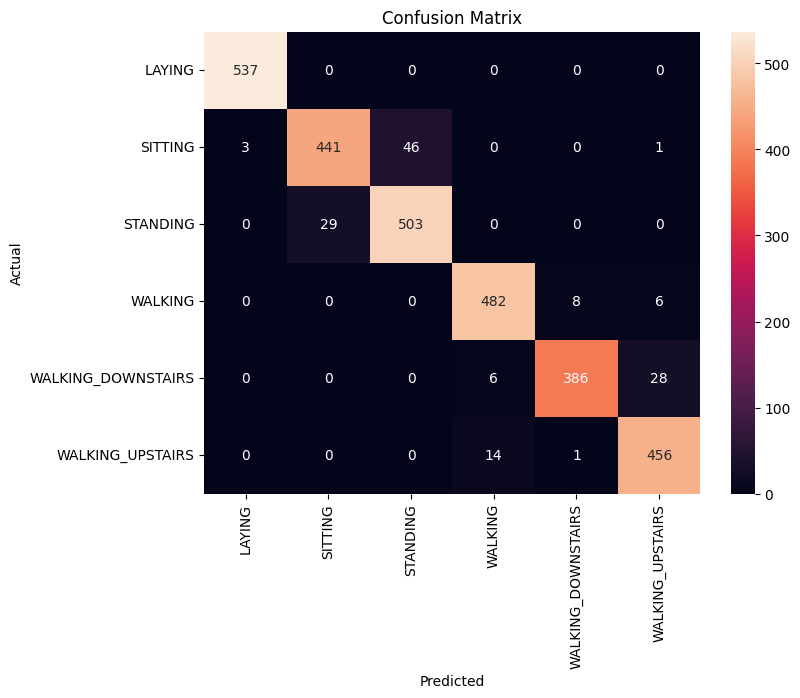


  SVM (RBF) — Overall Metrics
  Accuracy  : 0.9518
  Precision : 0.9522  (weighted)
  Recall    : 0.9518  (weighted)
  F1 Score  : 0.9517  (weighted)

Per-Class Report:

                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.94      0.90      0.92       491
          STANDING       0.92      0.95      0.93       532
           WALKING       0.96      0.97      0.97       496
WALKING_DOWNSTAIRS       0.98      0.92      0.95       420
  WALKING_UPSTAIRS       0.93      0.97      0.95       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [ ]:
name = "SVM (RBF)"
model = SVC(kernel='rbf', probability=True)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

plot_confusion_matrix(clf, y_pred, y_test)
print_metrics(name, y_test, y_pred)

## Understanding the Evaluation Metrics

| Metric | Formula | When It Matters |
|--------|---------|-----------------|
| **Accuracy** | $\frac{\text{Correct Predictions}}{\text{Total Predictions}}$ | Good overall indicator **when classes are balanced** (as in this dataset). |
| **Precision** | $\frac{TP}{TP + FP}$ | Important when **false positives are costly** — e.g., incorrectly telling a user they are "WALKING_DOWNSTAIRS" when they are actually "STANDING" could trigger a wrong action. |
| **Recall** | $\frac{TP}{TP + FN}$ | Important when **false negatives are costly** — e.g., failing to detect "WALKING_DOWNSTAIRS" could be a safety concern in fall-detection systems. |
| **F1 Score** | $2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ | The **harmonic mean** of Precision and Recall. Best single metric when you need a balance between the two. |

### Which metric is most useful here?

For this **multiclass activity-recognition** task:

- The dataset is roughly **balanced** across 6 activities, so **accuracy** is already a reliable metric.
- However, **weighted F1 score** is the most informative single number because it accounts for both false positives and false negatives across all classes, weighted by class support.
- If the system is used in a **safety-critical** application (e.g., elderly fall detection), **recall** for specific activities like *WALKING_DOWNSTAIRS* becomes the most important metric — missing a fall-related activity is far worse than a false alarm.

> **Recommendation:** Use **weighted F1 score** as the primary comparison metric across models, and inspect **per-class precision/recall** (from the classification report) to catch any class-specific weaknesses.

## 8. METHODOLOGY

---

Dataset:
The Human Activity Recognition (HAR) dataset from the UCI Machine Learning
Repository was used. It consists of sensor data collected from 30 subjects
performing daily activities while wearing a smartphone equipped with
accelerometer and gyroscope sensors.

Preprocessing:
The dataset’s predefined training and test split was
retained. Feature scaling was applied using standardization.

Models:
Three machine learning models were evaluated:

Logistic Regression as a linear baseline.

Random Forest to capture non-linear feature interactions.

Support Vector Machine with RBF kernel for high-dimensional separation.

Evaluation Metrics:
Models were evaluated using the confusion matrix.

## 9. RESULTS

---

RESULTS

All evaluated models achieved high classification performance, indicating that smartphone accelerometer and gyroscope features are highly effective for distinguishing multiple human activities.

Logistic Regression demonstrated strong baseline performance, suggesting that the extracted features provide good separability among different activity classes in the feature space. Random Forest further improved robustness and class-wise recall by capturing complex nonlinear relationships and interactions among the sensor-derived features. The Support Vector Machine with an RBF kernel achieved the best overall performance, highlighting its effectiveness in handling high-dimensional feature representations commonly found in human activity recognition datasets.

The confusion matrices and classification metrics show that most activities are accurately classified, with minor misclassifications occurring between activities that exhibit similar motion patterns, such as stationary activities. Overall, the results demonstrate that machine learning models can effectively learn discriminative patterns from smartphone sensor data for reliable multi-class human activity recognition.